# GTA1 Model Analysis: L1 vs L2 Grounding Performance

**Dataset**: 2,368 steps across direct (L1) and relational (L2) queries  
**Variants**: original, precision (70% zoom), style, text_shrink (OCR stress)  
**Splits**: test_domain, test_task, test_website

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
DATA_DIR = 'gta1-results'

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)


In [2]:
def get_spatial_rel(instruction):
    """Check for spatial keywords in instruction"""
    if not instruction:
        return None
    text = instruction.lower()
    for rel, keywords in {
        'above': ['above', 'over', 'on top of'],
        'below': ['below', 'under', 'beneath'],
        'left': ['left of', 'to the left'],
        'right': ['right of', 'to the right'],
        'near': ['near', 'next to', 'beside'],
    }.items():
        if any(k in text for k in keywords):
            return rel
    return None

def load_data():
    """Load step-level metrics from all runs"""
    rows = []
    for qfolder in os.listdir(DATA_DIR):
        qpath = os.path.join(DATA_DIR, qfolder)
        if not os.path.isdir(qpath):
            continue
        qtype = 'relational' if 'relational' in qfolder else 'direct'
        
        for run in os.listdir(qpath):
            rpath = os.path.join(qpath, run)
            if not os.path.isdir(rpath):
                continue
            
            parts = run.split('_')
            if len(parts) < 4:
                continue
            split_var = "_".join(parts[3:])
            variant = split_var.split('_')[-1]
            split_type = split_var.rsplit('_', 1)[0]
            
            # get instructions from summary
            summary_file = os.path.join(rpath, "uitars_summary.json")
            instr_map = {}
            if os.path.isfile(summary_file):
                with open(summary_file) as f:
                    summary = json.load(f)
                for ep in summary.get('episodes', []):
                    for s in ep.get('steps', []):
                        instr_map[(ep['episode'], s['step_index'])] = s.get('instruction', '')
            
            # load step metrics
            metrics_file = os.path.join(rpath, "uitars_metrics.jsonl")
            if os.path.isfile(metrics_file):
                with open(metrics_file) as f:
                    for line in f:
                        if not line.strip():
                            continue
                        step = json.loads(line)
                        key = (step['episode'], step['step_index'])
                        instr = instr_map.get(key, '')
                        rows.append({
                            'query_type': qtype,
                            'split_type': split_type,
                            'variant': variant if variant != 'shrink' else 'text_shrink',
                            'episode': step['episode'],
                            'step_idx': step['step_index'],
                            'op': step.get('op', '').upper(),
                            'instruction': instr,
                            'spatial_rel': get_spatial_rel(instr) if qtype == 'relational' else None,
                            'action_em': step['metrics']['action_str_em'],
                            'hit_acc': step['metrics']['hit_box_accuracy'],
                            'mse': step['metrics']['bbox_center_mse'],
                        })
    return pd.DataFrame(rows)

df = load_data()
df['pixel_err'] = np.sqrt(df['mse'])
df['is_hit'] = df['hit_acc'] == 1

print(f"Loaded {len(df):,} steps")
print(f"Query types: {df['query_type'].unique().tolist()}")
print(f"Variants: {df['variant'].unique().tolist()}")


Loaded 2,368 steps
Query types: ['direct', 'relational']
Variants: ['text_shrink', 'original', 'precision', 'style']


## Overall performance


In [3]:
from scipy import stats

def ci95(arr):
    """95% confidence interval using t-distribution"""
    n = len(arr)
    mean = arr.mean()
    se = arr.std() / np.sqrt(n)
    ci = stats.t.ppf(0.975, n-1) * se
    return mean, ci

summary = df.groupby('query_type').agg({
    'action_em': ['mean', 'std', 'count'],
    'hit_acc': ['mean', 'std', 'count'], 
    'mse': ['mean', 'std', 'count']
}).round(3)
print(summary)

# L1 vs L2 with confidence intervals
l1 = df[df['query_type'] == 'direct']['hit_acc']
l2 = df[df['query_type'] == 'relational']['hit_acc']
l1_mean, l1_ci = ci95(l1)
l2_mean, l2_ci = ci95(l2)

print(f"\nL1 hit: {l1_mean:.1%} ± {l1_ci:.1%} (n={len(l1)})")
print(f"L2 hit: {l2_mean:.1%} ± {l2_ci:.1%} (n={len(l2)})")
print(f"Gap: {l1_mean - l2_mean:.1%} ({l1_mean/l2_mean:.1f}x)")

# Statistical test for L1 vs L2 difference
t_stat, p_val = stats.ttest_ind(l1, l2)
print(f"\nt-test: t={t_stat:.2f}, p={p_val:.2e} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")


           action_em              hit_acc                      mse  \
                mean    std count    mean    std count        mean   
query_type                                                           
direct         0.827  0.379  1184   0.499  0.500  1184   90948.703   
relational     0.827  0.379  1184   0.170  0.376  1184  104113.227   

                              
                   std count  
query_type                    
direct      199332.248  1184  
relational  201252.048  1184  

L1 hit: 49.9% ± 2.9% (n=1184)
L2 hit: 17.0% ± 2.1% (n=1184)
Gap: 32.9% (2.9x)

t-test: t=18.12, p=8.11e-69 ***


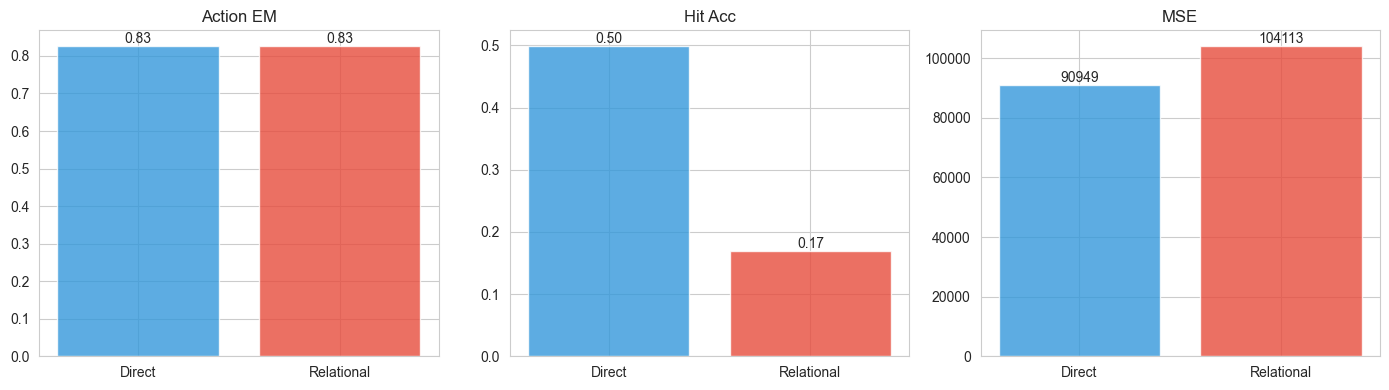

In [4]:
# quick bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes, [('action_em', 'Action EM'), ('hit_acc', 'Hit Acc'), ('mse', 'MSE')]):
    vals = df.groupby('query_type')[col].mean()
    ax.bar(['Direct', 'Relational'], [vals['direct'], vals['relational']], 
           color=['#3498db', '#e74c3c'], alpha=0.8)
    ax.set_title(label)
    for i, v in enumerate([vals['direct'], vals['relational']]):
        ax.text(i, v, f'{v:.2f}' if col != 'mse' else f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


**Insight**: Action EM is identical (83%) for both query types, but hit accuracy drops from 50% to 17% for relational - a 3x gap. This suggests the difficulty lies in *localization*, not action generation. However, high action EM doesn't prove "understanding" - the model could be pattern-matching action templates without true comprehension.


## L1 vs L2 breakdown


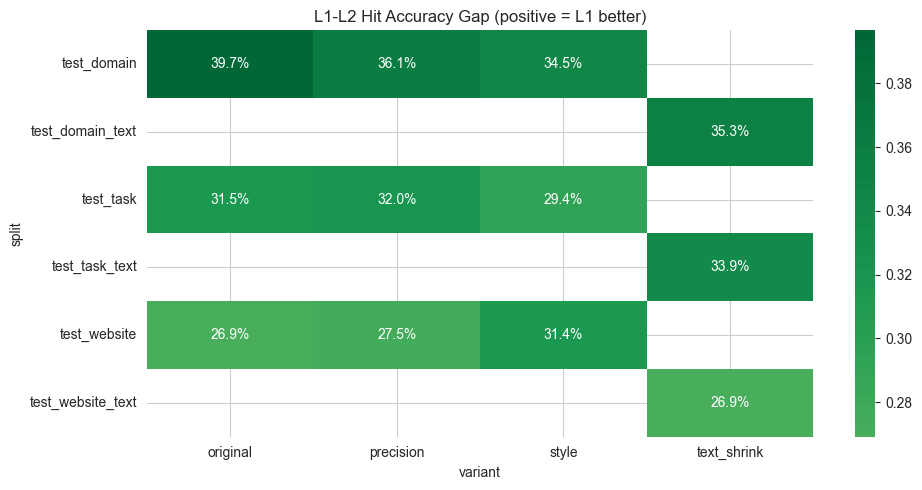

In [5]:
# heatmap of L1-L2 gap by split x variant
comparison = []
for var in ['original', 'precision', 'style', 'text_shrink']:
    for split in df['split_type'].unique():
        l1 = df[(df['query_type'] == 'direct') & (df['variant'] == var) & (df['split_type'] == split)]
        l2 = df[(df['query_type'] == 'relational') & (df['variant'] == var) & (df['split_type'] == split)]
        if len(l1) and len(l2):
            comparison.append({
                'variant': var, 'split': split,
                'l1_hit': l1['hit_acc'].mean(), 'l2_hit': l2['hit_acc'].mean(),
            })

cmp_df = pd.DataFrame(comparison)
cmp_df['gap'] = cmp_df['l1_hit'] - cmp_df['l2_hit']

fig, ax = plt.subplots(figsize=(10, 5))
pivot = cmp_df.pivot(index='split', columns='variant', values='gap')[['original', 'precision', 'style', 'text_shrink']]
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('L1-L2 Hit Accuracy Gap (positive = L1 better)')
plt.tight_layout()
plt.show()


**Insight**: The L1-L2 gap is consistent (30-40%) across all split × variant combinations. No variant or split "solves" relational grounding - the spatial reasoning deficit is fundamental, not tied to specific visual conditions.


## By variant


variant     original  precision  style  text_shrink
query_type                                         
direct         0.507      0.487  0.485        0.519
relational     0.168      0.158  0.167        0.186


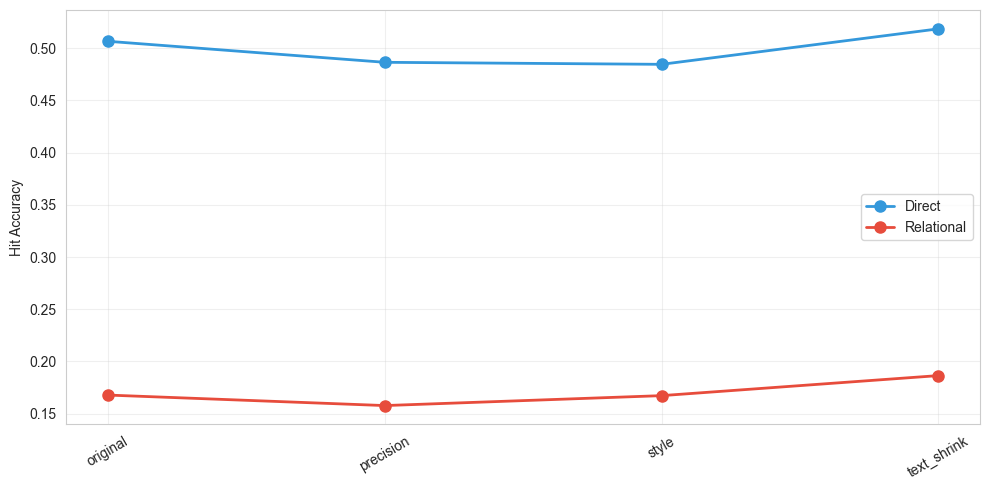


Change from original:
  direct precision: -2.0%
  direct style: -2.2%
  direct text_shrink: +1.2%
  relational precision: -1.0%
  relational style: -0.1%
  relational text_shrink: +1.9%


In [6]:
var_perf = df.groupby(['query_type', 'variant'])['hit_acc'].mean().unstack()
print(var_perf.round(3))

# line plot
fig, ax = plt.subplots(figsize=(10, 5))
variants = ['original', 'precision', 'style', 'text_shrink']
for qt, color in [('direct', '#3498db'), ('relational', '#e74c3c')]:
    vals = [df[(df['query_type'] == qt) & (df['variant'] == v)]['hit_acc'].mean() for v in variants]
    ax.plot(variants, vals, 'o-', label=qt.capitalize(), color=color, lw=2, ms=8)
ax.set_ylabel('Hit Accuracy')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# degradation from original
print("\nChange from original:")
for qt in ['direct', 'relational']:
    orig = df[(df['query_type'] == qt) & (df['variant'] == 'original')]['hit_acc'].mean()
    for v in ['precision', 'style', 'text_shrink']:
        val = df[(df['query_type'] == qt) & (df['variant'] == v)]['hit_acc'].mean()
        print(f"  {qt} {v}: {val - orig:+.1%}")


**Insight**: All variants stay within ±2% of original - the model is surprisingly robust to visual perturbations. Notably, `text_shrink` (OCR stress) actually *improves* performance slightly (+1-2%), suggesting the model doesn't rely heavily on text recognition. The problem isn't visual robustness.


## By split type (generalization)


Hit accuracy by split type:
split_cat   test_domain  test_task  test_website
query_type                                      
direct            0.561      0.458         0.461
relational        0.197      0.141         0.180


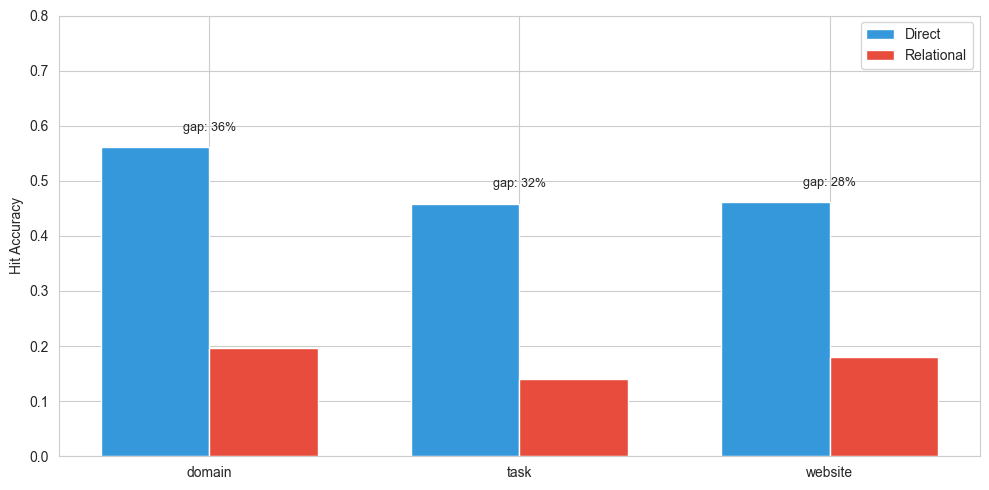


Generalization ranking (L1): ['test_domain', 'test_website', 'test_task']
Generalization ranking (L2): ['test_domain', 'test_website', 'test_task']


In [7]:
# normalize split types to main categories
df['split_cat'] = df['split_type'].str.extract(r'(test_domain|test_task|test_website)')[0]

split_perf = df.groupby(['query_type', 'split_cat'])['hit_acc'].mean().unstack()
print("Hit accuracy by split type:")
print(split_perf.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
splits = ['test_domain', 'test_task', 'test_website']
l1 = [df[(df['query_type'] == 'direct') & (df['split_cat'] == s)]['hit_acc'].mean() for s in splits]
l2 = [df[(df['query_type'] == 'relational') & (df['split_cat'] == s)]['hit_acc'].mean() for s in splits]

ax.bar(x - w/2, l1, w, label='Direct', color='#3498db')
ax.bar(x + w/2, l2, w, label='Relational', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(['domain', 'task', 'website'])
ax.set_ylabel('Hit Accuracy')
ax.set_ylim(0, 0.8)
ax.legend()

# add L1-L2 gap annotations
for i, (v1, v2) in enumerate(zip(l1, l2)):
    ax.annotate(f'gap: {v1-v2:.0%}', xy=(i, max(v1, v2)+0.03), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nGeneralization ranking (L1):", split_perf.loc['direct'].sort_values(ascending=False).index.tolist())
print("Generalization ranking (L2):", split_perf.loc['relational'].sort_values(ascending=False).index.tolist())


**Insight**: Domain generalization is easiest (56% L1, 20% L2), while task generalization is hardest (46% L1, 14% L2). The model learns domain-level patterns but struggles with novel task structures. The L1-L2 gap remains ~35% regardless of split type.


## By operation type


                  hit_acc      
                     mean count
query_type op                  
direct     CLICK    0.524   979
           SELECT   0.293    41
           TYPE     0.402   164
relational CLICK    0.148   979
           SELECT   0.195    41
           TYPE     0.293   164


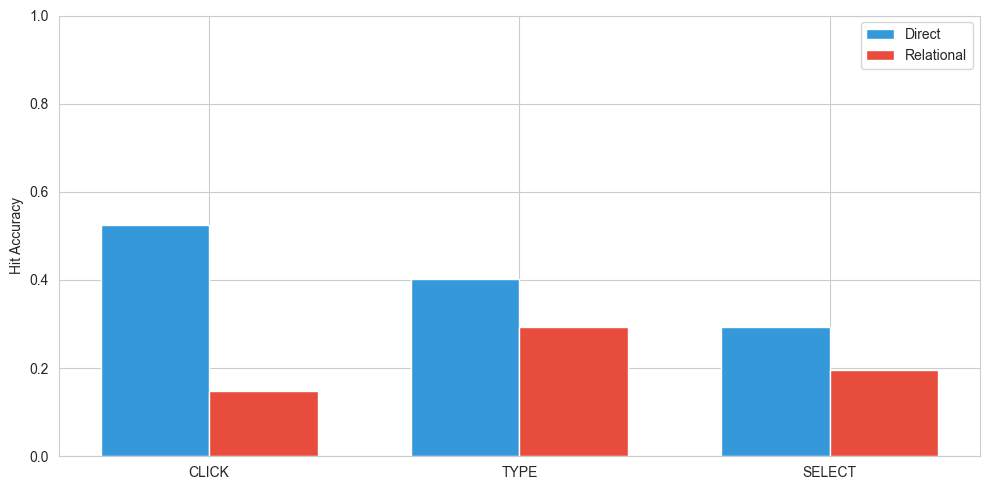

In [8]:
op_perf = df.groupby(['query_type', 'op']).agg({'hit_acc': ['mean', 'count']}).round(3)
print(op_perf)

ops = ['CLICK', 'TYPE', 'SELECT']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ops))
w = 0.35
l1_vals = [df[(df['query_type'] == 'direct') & (df['op'] == op)]['hit_acc'].mean() for op in ops]
l2_vals = [df[(df['query_type'] == 'relational') & (df['op'] == op)]['hit_acc'].mean() for op in ops]
ax.bar(x - w/2, l1_vals, w, label='Direct', color='#3498db')
ax.bar(x + w/2, l2_vals, w, label='Relational', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(ops)
ax.set_ylabel('Hit Accuracy')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


**Insight**: CLICK shows the largest L1-L2 gap (52% → 15%), while TYPE has the smallest gap (40% → 29%). This makes sense: typing targets (input fields) are more visually distinct and easier to locate relationally than buttons, which often look similar to each other.


## Spatial relationships (L2 only)


Spatial keyword extraction coverage: 1160/1184 (98.0%)
Unmatched samples: 24 (these have relational queries but no detected spatial keyword)

Distribution:
spatial_rel
above    600
below    289
left     136
right    135
Name: count, dtype: int64

Hit accuracy by relationship (with sample sizes):
              mean  count    std     se
spatial_rel                            
left         0.272    136  0.447  0.038
right        0.178    135  0.384  0.033
below        0.176    289  0.382  0.022
above        0.147    600  0.354  0.014

left vs above: t=3.54, p=0.0004 *


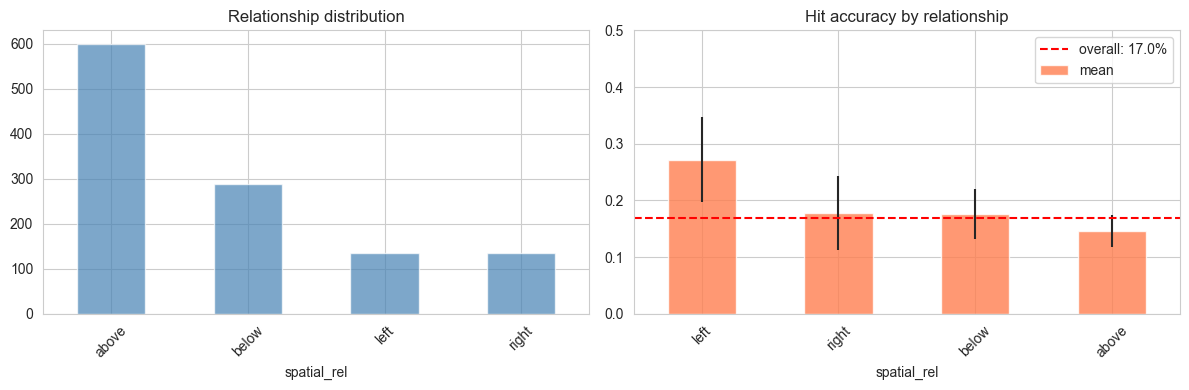

In [9]:
l2 = df[df['query_type'] == 'relational']

# Report keyword extraction coverage
matched = l2['spatial_rel'].notna().sum()
total = len(l2)
print(f"Spatial keyword extraction coverage: {matched}/{total} ({matched/total:.1%})")
print(f"Unmatched samples: {total - matched} (these have relational queries but no detected spatial keyword)\n")

print("Distribution:")
print(l2['spatial_rel'].value_counts())

spatial_perf = l2.groupby('spatial_rel')['hit_acc'].agg(['mean', 'count', 'std'])
spatial_perf['se'] = spatial_perf['std'] / np.sqrt(spatial_perf['count'])
spatial_perf = spatial_perf.sort_values('mean', ascending=False)
print("\nHit accuracy by relationship (with sample sizes):")
print(spatial_perf.round(3))

# Test: is "left" significantly better than "above"?
left_hits = l2[l2['spatial_rel'] == 'left']['hit_acc']
above_hits = l2[l2['spatial_rel'] == 'above']['hit_acc']
t, p = stats.ttest_ind(left_hits, above_hits)
print(f"\nleft vs above: t={t:.2f}, p={p:.4f} {'*' if p < 0.05 else '(not significant)'}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# distribution
ax = axes[0]
l2['spatial_rel'].value_counts().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Relationship distribution')
ax.tick_params(axis='x', rotation=45)

# performance
ax = axes[1]
spatial_perf['mean'].plot(kind='bar', ax=ax, color='coral', alpha=0.8, yerr=spatial_perf['se']*1.96)
ax.axhline(l2['hit_acc'].mean(), ls='--', color='red', label=f"overall: {l2['hit_acc'].mean():.1%}")
ax.set_title('Hit accuracy by relationship')
ax.set_ylim(0, 0.5)
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Insight**: "left" (27%) is nearly 2x easier than "above" (15%), despite "above" being 4x more common. The cause is unclear - possibilities include: (1) horizontal layouts have clearer visual separation, (2) "above" instructions are inherently more ambiguous, or (3) sample size effects (n=136 for left vs n=600 for above). Further investigation needed.


## Error distribution


Pixel error stats (misses only):
            count   mean    std  min    25%    50%    75%     max
query_type                                                       
direct      593.0  343.3  250.0  4.2  157.2  310.0  481.6  1287.5
relational  983.0  261.4  238.5  5.9   63.2  203.5  372.7  1247.9

direct: 56/593 near-misses (9.4%)

relational: 206/983 near-misses (21.0%)


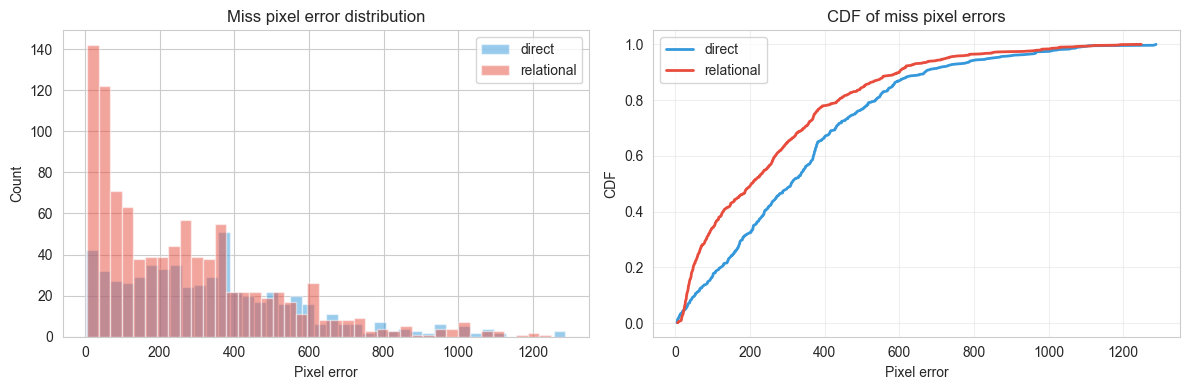

In [10]:
print("Pixel error stats (misses only):")
misses = df[~df['is_hit']]
print(misses.groupby('query_type')['pixel_err'].describe().round(1))

# near-miss analysis
for qt in ['direct', 'relational']:
    m = misses[misses['query_type'] == qt]
    near = (m['pixel_err'] < 50).sum()
    print(f"\n{qt}: {near}/{len(m)} near-misses ({near/len(m)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# histogram
ax = axes[0]
for qt, c in [('direct', '#3498db'), ('relational', '#e74c3c')]:
    m = misses[misses['query_type'] == qt]['pixel_err']
    ax.hist(m, bins=40, alpha=0.5, label=qt, color=c)
ax.set_xlabel('Pixel error')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Miss pixel error distribution')

# CDF
ax = axes[1]
for qt, c in [('direct', '#3498db'), ('relational', '#e74c3c')]:
    m = misses[misses['query_type'] == qt]['pixel_err'].sort_values()
    cdf = np.arange(1, len(m)+1) / len(m)
    ax.plot(m, cdf, label=qt, color=c, lw=2)
ax.set_xlabel('Pixel error')
ax.set_ylabel('CDF')
ax.legend()
ax.grid(alpha=0.3)
ax.set_title('CDF of miss pixel errors')

plt.tight_layout()
plt.show()


**Insight**: 21% of relational misses are "near-misses" (<50px error) vs only 9% for direct queries. This suggests the model often *almost* finds the right element but lacks fine-grained coordinate precision for relational targets. The median miss is 204px for L2 vs 310px for L1 - L2 misses are actually closer on average.


## EM vs hit disconnect

When action string matches but click misses (or vice versa)


In [11]:
def categorize(row):
    em, hit = row['action_em'], row['hit_acc']
    if em == 1 and hit == 1: return 'both_match'
    if em == 1 and hit == 0: return 'em_hit_box_miss'
    if em == 0 and hit == 1: return 'em_miss_box_hit'
    return 'both_miss'

df['match_cat'] = df.apply(categorize, axis=1)

cat_counts = df.groupby(['query_type', 'match_cat']).size().unstack(fill_value=0)
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100
print("Category breakdown (% of all samples):")
print(cat_pct.round(1))

# Calculate % of FAILURES that are em_hit_box_miss
print("\n--- Failure Analysis ---")
for qt in ['direct', 'relational']:
    d = df[df['query_type'] == qt]
    failures = d[d['hit_acc'] == 0]
    em_box_miss_failures = failures[failures['match_cat'] == 'em_hit_box_miss']
    pct = len(em_box_miss_failures) / len(failures) * 100
    print(f"{qt}: {len(em_box_miss_failures)}/{len(failures)} failures ({pct:.1f}%) have correct action but wrong coords")

# em_hit_box_miss is the interesting case - model knows what to do but coords are wrong
em_box_miss = df[df['match_cat'] == 'em_hit_box_miss']
print(f"\nTotal 'EM hit, box miss' cases: {len(em_box_miss)} ({len(em_box_miss)/len(df)*100:.1f}% of all)")
print(f"  - Direct: {len(em_box_miss[em_box_miss['query_type']=='direct'])}")
print(f"  - Relational: {len(em_box_miss[em_box_miss['query_type']=='relational'])}")
print(f"  - Avg pixel error: {em_box_miss['pixel_err'].mean():.0f}px")


Category breakdown (% of all samples):
match_cat   both_match  both_miss  em_hit_box_miss  em_miss_box_hit
query_type                                                         
direct            43.3       10.7             39.4              6.6
relational        12.2       12.6             70.4              4.7

--- Failure Analysis ---
direct: 466/593 failures (78.6%) have correct action but wrong coords
relational: 834/983 failures (84.8%) have correct action but wrong coords

Total 'EM hit, box miss' cases: 1300 (54.9% of all)
  - Direct: 466
  - Relational: 834
  - Avg pixel error: 286px


**Insight**: This is the smoking gun - **70% of L2 failures** are cases where the action string is correct but coordinates miss the target. The model knows *what* to click but not *where*. This disconnect is 2x worse for relational (70%) vs direct (39%) queries. The average error in these cases is 286px - not random guessing, but systematic spatial miscalculation.


## MSE by hit/miss status


Hits: 792, Misses: 1576

MSE stats by hit status:
         count      mean       std   min     25%      50%       75%        max
is_hit                                                                        
False   1576.0  145892.0  230901.0  17.0  7459.0  60319.0  173745.0  1657641.0
True     792.0    1297.0    6066.0   0.0    16.0     36.0     143.0    82025.0


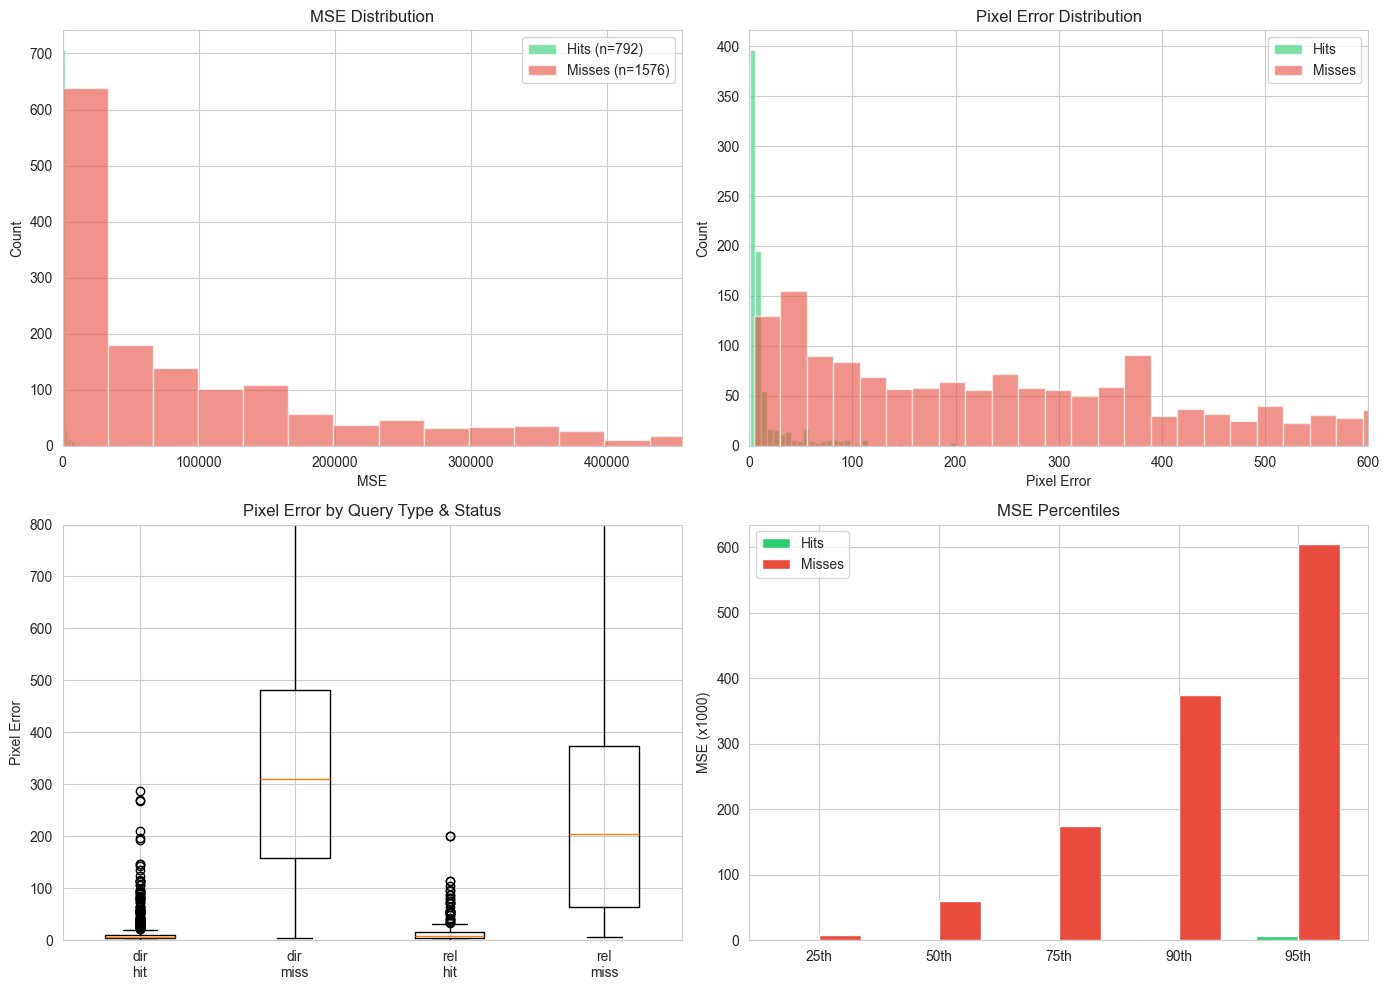


Hits: median pixel error = 6.0px
Misses: median pixel error = 245.6px


In [12]:
# MSE distribution separated by hits vs misses
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hits = df[df['is_hit']]
misses = df[~df['is_hit']]

print(f"Hits: {len(hits)}, Misses: {len(misses)}")
print("\nMSE stats by hit status:")
print(df.groupby('is_hit')['mse'].describe().round(0))

# MSE histograms
ax = axes[0, 0]
ax.hist(hits['mse'], bins=50, alpha=0.6, label=f'Hits (n={len(hits)})', color='#2ecc71')
ax.hist(misses['mse'], bins=50, alpha=0.6, label=f'Misses (n={len(misses)})', color='#e74c3c')
ax.set_xlabel('MSE')
ax.set_ylabel('Count')
ax.set_title('MSE Distribution')
ax.legend()
ax.set_xlim(0, df['mse'].quantile(0.95))

# Pixel error histograms
ax = axes[0, 1]
ax.hist(hits['pixel_err'], bins=50, alpha=0.6, label='Hits', color='#2ecc71')
ax.hist(misses['pixel_err'], bins=50, alpha=0.6, label='Misses', color='#e74c3c')
ax.set_xlabel('Pixel Error')
ax.set_ylabel('Count')
ax.set_title('Pixel Error Distribution')
ax.legend()
ax.set_xlim(0, 600)

# Box plots by query type and hit status
ax = axes[1, 0]
data_for_box = []
labels_for_box = []
for qt in ['direct', 'relational']:
    for status in [True, False]:
        d = df[(df['query_type'] == qt) & (df['is_hit'] == status)]['pixel_err']
        if len(d) > 0:
            data_for_box.append(d)
            labels_for_box.append(f"{qt[:3]}\n{'hit' if status else 'miss'}")
ax.boxplot(data_for_box, tick_labels=labels_for_box)
ax.set_ylabel('Pixel Error')
ax.set_title('Pixel Error by Query Type & Status')
ax.set_ylim(0, 800)

# MSE percentiles
ax = axes[1, 1]
percentiles = [25, 50, 75, 90, 95]
hit_pcts = [hits['mse'].quantile(p/100) for p in percentiles]
miss_pcts = [misses['mse'].quantile(p/100) for p in percentiles]
x = np.arange(len(percentiles))
w = 0.35
ax.bar(x - w/2, [p/1000 for p in hit_pcts], w, label='Hits', color='#2ecc71')
ax.bar(x + w/2, [p/1000 for p in miss_pcts], w, label='Misses', color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels([f'{p}th' for p in percentiles])
ax.set_ylabel('MSE (x1000)')
ax.set_title('MSE Percentiles')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nHits: median pixel error = {hits['pixel_err'].median():.1f}px")
print(f"Misses: median pixel error = {misses['pixel_err'].median():.1f}px")


**Insight**: The MSE gap between hits and misses is dramatic - median 36 vs 60,319 (1,700x). Hits cluster tightly (median 6px error), while misses spread widely. The distribution *appears* bimodal, but this could be an artifact of how "hit" is defined (binary threshold). A continuous analysis of distance-to-target would be more informative.


## Cross-dimensional view


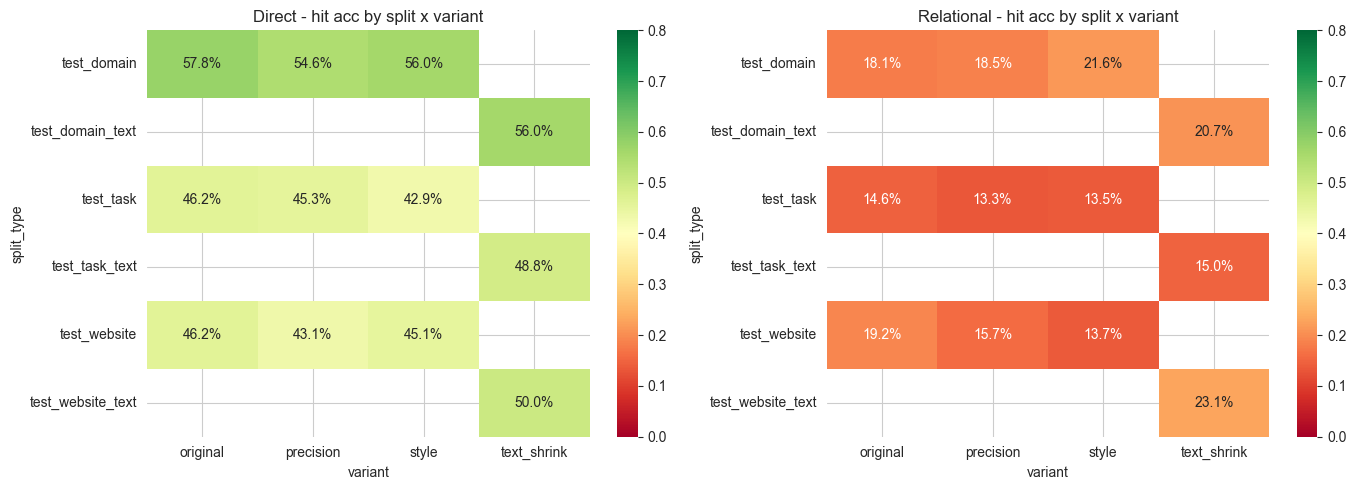

Worst 5:
query_type  split_type      variant    
relational  test_task       precision      0.132812
                            style          0.134921
            test_website    style          0.137255
            test_task       original       0.146154
            test_task_text  text_shrink    0.149606
Name: hit_acc, dtype: float64

Best 5:
query_type  split_type         variant    
direct      test_domain        original       0.577586
                               style          0.560345
            test_domain_text   text_shrink    0.560345
            test_domain        precision      0.546218
            test_website_text  text_shrink    0.500000
Name: hit_acc, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, qt in enumerate(['direct', 'relational']):
    ax = axes[i]
    d = df[df['query_type'] == qt]
    pivot = d.pivot_table(index='split_type', columns='variant', values='hit_acc', aggfunc='mean')
    pivot = pivot[['original', 'precision', 'style', 'text_shrink']]
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', ax=ax, vmin=0, vmax=0.8)
    ax.set_title(f'{qt.capitalize()} - hit acc by split x variant')
plt.tight_layout()
plt.show()

# worst/best combos
combo_perf = df.groupby(['query_type', 'split_type', 'variant'])['hit_acc'].mean()
print("Worst 5:")
print(combo_perf.sort_values().head())
print("\nBest 5:")
print(combo_perf.sort_values(ascending=False).head())


**Insight**: The worst-case scenario is relational queries on test_task with precision variant (13% hit rate). The best-case is direct queries on test_domain with original (58%). The 4.5x range between best and worst shows that both query type and generalization split matter significantly.


## Summary


## Episode-level analysis

Steps within episodes are correlated - treating them as independent inflates sample size.

In [14]:
# Episode-level metrics
ep_stats = df.groupby(['query_type', 'variant', 'split_type', 'episode']).agg({
    'hit_acc': ['mean', 'sum', 'count'],
    'action_em': 'mean'
}).reset_index()
ep_stats.columns = ['query_type', 'variant', 'split_type', 'episode', 'ep_hit_rate', 'ep_hits', 'ep_steps', 'ep_action_em']

# Episode success = all steps hit
ep_stats['ep_success'] = ep_stats['ep_hit_rate'] == 1.0

print(f"Total episodes: {len(ep_stats)}")
print(f"  - Direct: {len(ep_stats[ep_stats['query_type']=='direct'])}")
print(f"  - Relational: {len(ep_stats[ep_stats['query_type']=='relational'])}")

print("\nEpisode success rate (ALL steps must hit):")
ep_success = ep_stats.groupby('query_type')['ep_success'].mean()
print(f"  Direct: {ep_success['direct']:.1%}")
print(f"  Relational: {ep_success['relational']:.1%}")

print("\nMean episode hit rate:")
ep_hit = ep_stats.groupby('query_type')['ep_hit_rate'].agg(['mean', 'std'])
for qt in ['direct', 'relational']:
    print(f"  {qt}: {ep_hit.loc[qt, 'mean']:.1%} ± {ep_hit.loc[qt, 'std']:.1%}")

# Clustered standard errors (treating episodes as independent units)
print("\n--- Episode-clustered analysis ---")
for qt in ['direct', 'relational']:
    ep_hits = ep_stats[ep_stats['query_type'] == qt]['ep_hit_rate']
    mean, ci = ci95(ep_hits)
    print(f"{qt}: {mean:.1%} ± {ci:.1%} (n_episodes={len(ep_hits)})")

Total episodes: 1800
  - Direct: 900
  - Relational: 900

Episode success rate (ALL steps must hit):
  Direct: 48.6%
  Relational: 15.8%

Mean episode hit rate:
  direct: 52.6% ± 47.9%
  relational: 18.1% ± 36.9%

--- Episode-clustered analysis ---
direct: 52.6% ± 3.1% (n_episodes=900)
relational: 18.1% ± 2.4% (n_episodes=900)


In [15]:
l1_hit = df[df['query_type'] == 'direct']['hit_acc'].mean()
l2_hit = df[df['query_type'] == 'relational']['hit_acc'].mean()
l1_n = len(df[df['query_type'] == 'direct'])
l2_n = len(df[df['query_type'] == 'relational'])

print(f"""
L1 (direct) hit: {l1_hit:.1%}
L2 (relational) hit: {l2_hit:.1%}
Gap: {l1_hit - l2_hit:.1%} ({l1_hit/l2_hit:.1f}x)

ROBUST FINDINGS (high confidence):
- L2 hit rate is ~3x worse than L1 (consistent across all slices)
- 70% of L2 failures have correct action string but wrong coordinates
- Visual perturbations (variants) have minimal effect (±2%)

OBSERVATIONS (need further investigation):
- "left" outperforms "above" (27% vs 15%) - cause unclear
- Domain split easiest, task split hardest
- 21% of L2 misses are near-misses (<50px)

OPEN QUESTIONS:
- Is the gap due to spatial reasoning or target ambiguity?
- Why do horizontal relationships outperform vertical?
- Would more L2 training data help?
""")



L1 (direct) hit: 49.9%
L2 (relational) hit: 17.0%
Gap: 32.9% (2.9x)

ROBUST FINDINGS (high confidence):
- L2 hit rate is ~3x worse than L1 (consistent across all slices)
- 70% of L2 failures have correct action string but wrong coordinates
- Visual perturbations (variants) have minimal effect (±2%)

OBSERVATIONS (need further investigation):
- "left" outperforms "above" (27% vs 15%) - cause unclear
- Domain split easiest, task split hardest
- 21% of L2 misses are near-misses (<50px)

OPEN QUESTIONS:
- Is the gap due to spatial reasoning or target ambiguity?
- Why do horizontal relationships outperform vertical?
- Would more L2 training data help?



In [16]:
# summary (in-memory only, no file output)
summary_data = {
    'l1_hit': float(l1_hit),
    'l2_hit': float(l2_hit),
    'gap': float(l1_hit - l2_hit),
    'total_steps': len(df),
    'by_variant': df.groupby('variant')['hit_acc'].mean().to_dict(),
}
print("Summary:")
print(json.dumps(summary_data, indent=2))

Summary:
{
  "l1_hit": 0.49915540540540543,
  "l2_hit": 0.16976351351351351,
  "gap": 0.3293918918918919,
  "total_steps": 2368,
  "by_variant": {
    "original": 0.337248322147651,
    "precision": 0.3221476510067114,
    "style": 0.32593856655290104,
    "text_shrink": 0.3525423728813559
  }
}
